In [2]:
import numpy as np
import pandas
from sklearn.linear_model import Lasso
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit

In [3]:
#Dynamic search path configuration
import sys
import os

#Adjusting search path based on notebook's depth in directory --> iterates through directories until it finds directory name: US_conflict_forecasting
current_dir = os.getcwd()
while 'US_conflict_forecasting' not in os.path.basename(current_dir):
    current_dir = os.path.dirname(current_dir)

#Adjusting search path based on 'new' current directory
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from project_setup import setup_project
project_root_dir = setup_project()

import pandas as pd

Current Project Root Directory set to: /Users/danie/Desktop/Hertie/2. Semester/1. ML/0. Final Project/US_conflict_forecasting
Current Search Path set to: ['c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting', 'c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting\\3_Models', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32\\lib', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\Pythonwin', 'c:\\Users\\danie\\AppData\

In [4]:
# Load the data

data = pd.read_csv(os.path.join(project_root_dir, '2_Dataset/d_Final_Dataset/Final_Dataset_Lag_clean.csv'))

In [5]:
train = data[data['month'] <= 9]

test = data[data['month'] > 9]

In [6]:
X_train = train.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_train = train['event_count']


X_test = test.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_test = test['event_count']

In [7]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
X_train_1, X_val, y_train_1, y_val = train_test_split(X_train, Y_train, test_size = 0.2, random_state= 1)


In [9]:
alphas = np.logspace(-2, 2, 10)

In [10]:
alpha_values = []
mse_values = []
best_alpha = None
lowest_mse = np.inf

for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train_1, y_train_1)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    
    alpha_values.append(alpha)
    mse_values.append(mse)
    
    if mse < lowest_mse:
        best_alpha = alpha
        lowest_mse = mse

c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.820e+02, tolerance: 4.327e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.124e+02, tolerance: 4.327e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

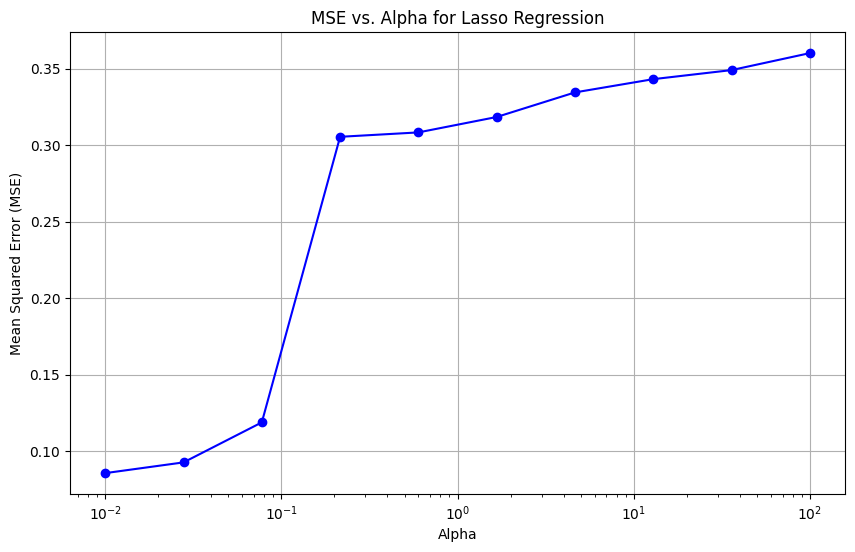

In [11]:
plt.figure(figsize=(10, 6))
plt.semilogx(alpha_values, mse_values, marker='o', linestyle='-', color='b')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs. Alpha for Lasso Regression')
plt.grid(True)
plt.show()

In [12]:
print(f"Best Alpha: {best_alpha}")
print(f"Lowest MSE: {lowest_mse}")

Best Alpha: 0.01
Lowest MSE: 0.0857399137136902


In [13]:
final_lasso_model = Lasso(alpha=best_alpha)

In [14]:
X_train_val = np.vstack((X_train_1, X_val))
y_train_val = np.concatenate((y_train_1, y_val))

In [15]:
final_lasso_model.fit(X_train_val, y_train_val)

c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.437e+02, tolerance: 5.575e-01
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.01)

In [16]:
y_test_pred_lasso = final_lasso_model.predict(X_test)


c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


In [17]:
final_test_mse_lasso = mean_squared_error(Y_test, y_test_pred_lasso)


In [18]:
print(f"Final Test MSE for Lasso: {final_test_mse_lasso}")


Final Test MSE for Lasso: 0.1060084658247004


In [22]:
# Print which features were selected by Lasso
selected_features = X_train.columns[final_lasso_model.coef_ != 0]

print(f"Selected Features: {selected_features}")

Selected Features: Index(['set_peaceful_prot', 'neighbor_conflicts', 'event_count_prev_year',
       'event_count_prev_month', 'Population, 2020',
       '# Square Land Miles, 2020', 'Population per Square Land Mile, 2022',
       'Total Population, 2022', 'Males, 2022', 'Females, 2022',
       ...
       'Homeowners with Mortgage Whose Housing Costs was Calculated, 2022',
       'Homeowners with Mortgage Paying <30% Income for Housing Cost, 2022',
       'Homeowners with Mortgage Paying 30% to 49%  Income for Housing Cost, 2022',
       'Homeowners with Mortgage Paying 50%+  Income for Housing Cost, 2022',
       '# Households Paying Cash Rent', 'Median Gross Rent, 2022',
       '# Renters for Whom Income to Rent Ratio was Determined, 2022',
       '30% to 49% of Income for Rent, 2022', '50%+ of Income for Rent, 2022',
       'topic2'],
      dtype='object', length=164)


In [23]:
# Print which features were set to 0 by Lasso

zeroed_features = X_train.columns[final_lasso_model.coef_ == 0]

print(f"Zeroed Features: {zeroed_features}")

Zeroed Features: Index(['fatalities', 'act_gov', 'act_pol', 'act_nat', 'act_rel', 'act_edu',
       'act_wor', 'act_iss', 'act_rwm', 'act_oth', 'set_other', 'set_prot_int',
       'set_mob', 'set_violent_prot', 'set_loot_destr', 'unions',
       'environment', 'gun-violence', 'healthcare',
       'Rural_Urban_Commerical Status',
       'K-12 Grade Students Enrolled in Public School, 2022', 'Veterans, 2022',
       'Veterans, 2022.1', 'People <65 years Old with No Health Insurance',
       'Households with Internet Access, 2022',
       'Married-couples with Own Children (<18) Households, 2022',
       'Total # Employed People, 2022', 'Worked from Home, 2022',
       '# Employed Person Not Working at Home, 2022',
       'Vacant Units for Seasonal, Rec., or Occasional Use, 2022',
       '<30% of Income for Rent', 'topic0', 'topic1', 'topic3', 'topic4',
       'topic5', 'topic6', 'topic7', 'topic8', 'topic9', 'topic10', 'topic11',
       'topic12', 'topic13', 'topic14'],
      dtype='obje